# The floruit field

In [1]:
import duckdb
import matplotlib.pyplot as plt
import polars as pl
from style import *

DB_PATH = '../data/cultura/humans_clean_enriched_v3.duckdb'
CV_PATH = '../data/similar_databases/cross_verified.duckdb'

FIRST_CENTURY = -1000
LAST_CENTURY = 2000
PRECISION_ORDER = ['day', 'month', 'year', 'decade']
MID_DECADE = 5

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(80)

apply_style()

connection = duckdb.connect(DB_PATH, read_only=True)
connection.execute(f"ATTACH '{CV_PATH}' AS cv (READ_ONLY)")

## Format

In [2]:
connection.execute('''
    SELECT count(*) AS individuals,
           count(*) FILTER (WHERE len(floruit_date) > 0) AS with_floruit,
           max(len(floruit_date)) AS most_entries_on_one_individual
    FROM individual
''').pl()

individuals,with_floruit,most_entries_on_one_individual
i64,i64,i64
13002897,87467,2


In [3]:
connection.execute('''
    SELECT individual.entity.label_en AS name, individual.entity.description,
           floruit_date[1].iso AS iso, floruit_date[1].year AS year, floruit_date[1].precision AS precision,
           floruit_date[1].field_provenance['year'].raw AS provenance_raw
    FROM individual
    WHERE len(floruit_date) > 0
    ORDER BY hash(individual.entity.qid)
    LIMIT 8
''').pl()

name,description,iso,year,precision,provenance_raw
str,str,str,i64,str,list[str]
"""Florentius""",null,"""0300-01-01""",300,"""century""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Eulogio Rodriguez""","""President of the Senate of the Philippines from 1954 to 1963, 1952 to 1953""",null,1954,"""year""","[""Individual.entity""]"
"""Adlai Stevenson III""","""Democratic U.S. Senator from Illinois from 1970 to 1981""",null,1970,"""year""","[""Individual.entity""]"
"""Amblare""",null,"""1177-01-01""",1177,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Ingela M Grumme""",null,"""2014-01-01""",2014,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Rein van Houts""",null,"""1945-01-01""",1945,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Walter G. Joyce""","""American/Swiss paleontologist""","""2015-01-01""",2015,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"
"""Hillary Joy Kipnis""",null,"""1987-01-01""",1987,"""year""","[""IndividualWikidata.floruit"", ""IndividualWikidata.floruit_precision""]"


## Load the floruit individuals

In [4]:
floruit = connection.execute('''
    SELECT individual.entity.qid AS qid,
           floruit_date[1].year AS year,
           coalesce(floruit_date[1].precision, 'unknown') AS precision,
           CASE WHEN floruit_date[1].field_provenance['year'].ai_answer.prompt_id = 'wikipedia_dates'
                THEN 'Wikipedia article' ELSE 'Wikidata P1317' END AS source,
           len(birth_date) > 0 AS has_birth,
           len(death_date) > 0 AS has_death,
           coalesce(cv.level1_main_occ, 'Not in CV') AS category,
           coalesce(birth_country.present_day_state.continent,
                    death_country.present_day_state.continent,
                    citizenship.present_day_state.continent,
                    'No location') AS region
    FROM individual
    LEFT JOIN cv.individuals AS cv ON cv.wikidata_code = individual.entity.qid
    LEFT JOIN place AS birthplace ON birthplace.entity.qid = individual.place_of_birth.entity.qid
    LEFT JOIN place AS birth_country ON birth_country.entity.qid = birthplace.country.qid
    LEFT JOIN place AS deathplace ON deathplace.entity.qid = individual.place_of_death.entity.qid
    LEFT JOIN place AS death_country ON death_country.entity.qid = deathplace.country.qid
    LEFT JOIN place AS citizenship ON citizenship.entity.qid = individual.country_of_citizenship[1].entity.qid
    WHERE len(floruit_date) > 0
''').pl()

print(f'{len(floruit):,} individuals with a floruit')

87,467 individuals with a floruit


## Source and precision

In [5]:
floruit.filter(pl.col('precision').is_in(PRECISION_ORDER)).group_by('source', 'precision').len().sort('source', 'len', descending=[False, True])

source,precision,len
str,str,u32
"""Wikidata P1317""","""year""",67470
"""Wikidata P1317""","""decade""",2429
"""Wikidata P1317""","""day""",1051
"""Wikidata P1317""","""month""",349


## Keep the year-level floruits only

In [6]:
dropped = floruit.filter(~pl.col('precision').is_in(PRECISION_ORDER))
floruit = (
    floruit.filter(pl.col('precision').is_in(PRECISION_ORDER))
    .with_columns(pl.when(pl.col('precision') == 'decade').then(pl.col('year') + MID_DECADE).otherwise(pl.col('year')).alias('year'))
    .with_columns((pl.col('year') // 100 * 100).alias('century_start'))
)
print(f'{len(floruit):,} year-level floruits kept, {len(dropped):,} century, millennium or undated ones left out')

71,299 year-level floruits kept, 16,168 century, millennium or undated ones left out


## Other dates beside the floruit

In [7]:
floruit.group_by('has_birth', 'has_death').len().sort('len', descending=True).with_columns(
    (pl.col('len') / pl.col('len').sum() * 100).round(1).alias('percent')
)

has_birth,has_death,len,percent
bool,bool,u32,f64
false,false,42103,59.1
true,true,20113,28.2
true,false,8888,12.5
false,true,195,0.3


## By century

217 individuals before -1000 left out of the chart
15 individuals with a floruit after 2099 — data errors — left out of the chart


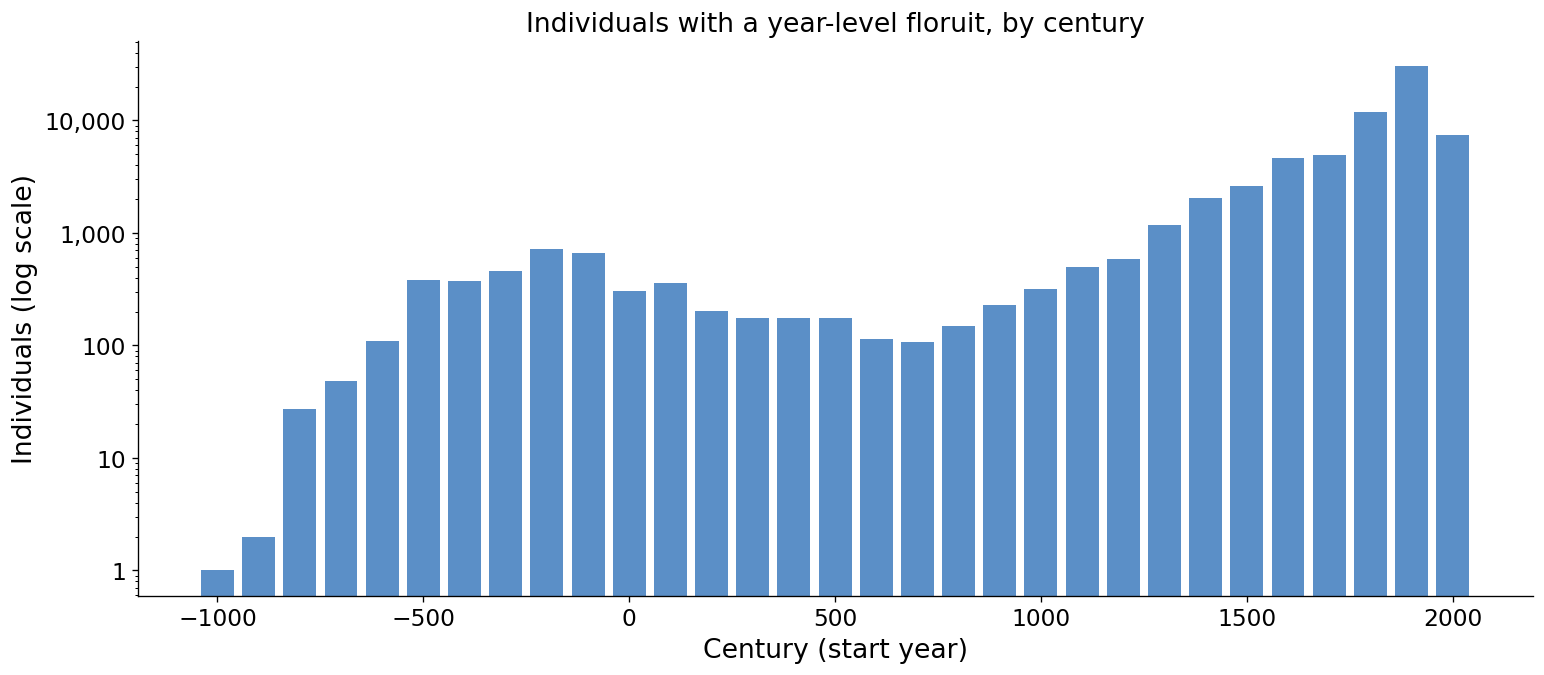

In [8]:
by_century = (
    floruit.filter(pl.col('century_start').is_between(FIRST_CENTURY, LAST_CENTURY))
    .group_by('century_start').len()
    .sort('century_start')
)
print(f"{floruit.filter(pl.col('century_start') < FIRST_CENTURY).height:,} individuals before {FIRST_CENTURY} left out of the chart")
print(f"{floruit.filter(pl.col('century_start') > LAST_CENTURY).height:,} individuals with a floruit after {LAST_CENTURY + 99} — data errors — left out of the chart")

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.bar(by_century['century_start'], by_century['len'], width=80, color=MAIN_COLOR)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:,.0f}'))
ax.set_xlabel('Century (start year)')
ax.set_ylabel('Individuals (log scale)')
ax.set_title('Individuals with a year-level floruit, by century')
plt.show()

In [9]:
floruit.group_by('century_start').len().sort('century_start').filter(pl.col('century_start').is_between(FIRST_CENTURY, LAST_CENTURY)).with_columns(
    (pl.col('len') / pl.col('len').sum() * 100).round(1).alias('percent')
)

century_start,len,percent
i64,u32,f64
-1000,1,0.0
-900,2,0.0
-800,27,0.0
-700,48,0.1
-600,110,0.2
-500,381,0.5
-400,377,0.5
-300,459,0.6
-200,716,1.0


## By cross-verified occupation category

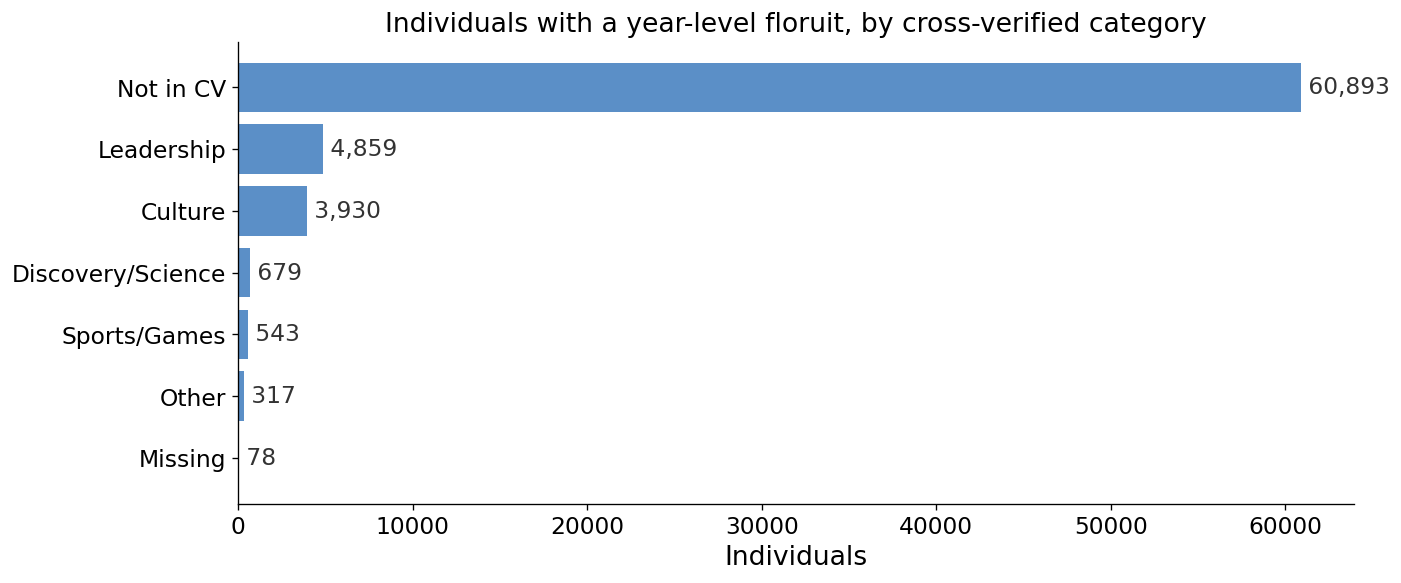

In [10]:
by_category = floruit.group_by('category').len().sort('len')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.barh(by_category['category'], by_category['len'], color=MAIN_COLOR)
for y, value in enumerate(by_category['len']):
    ax.text(value, y, f' {value:,}', va='center', color=TEXT)
ax.set_xlabel('Individuals')
ax.set_title('Individuals with a year-level floruit, by cross-verified category')
plt.show()

## By region

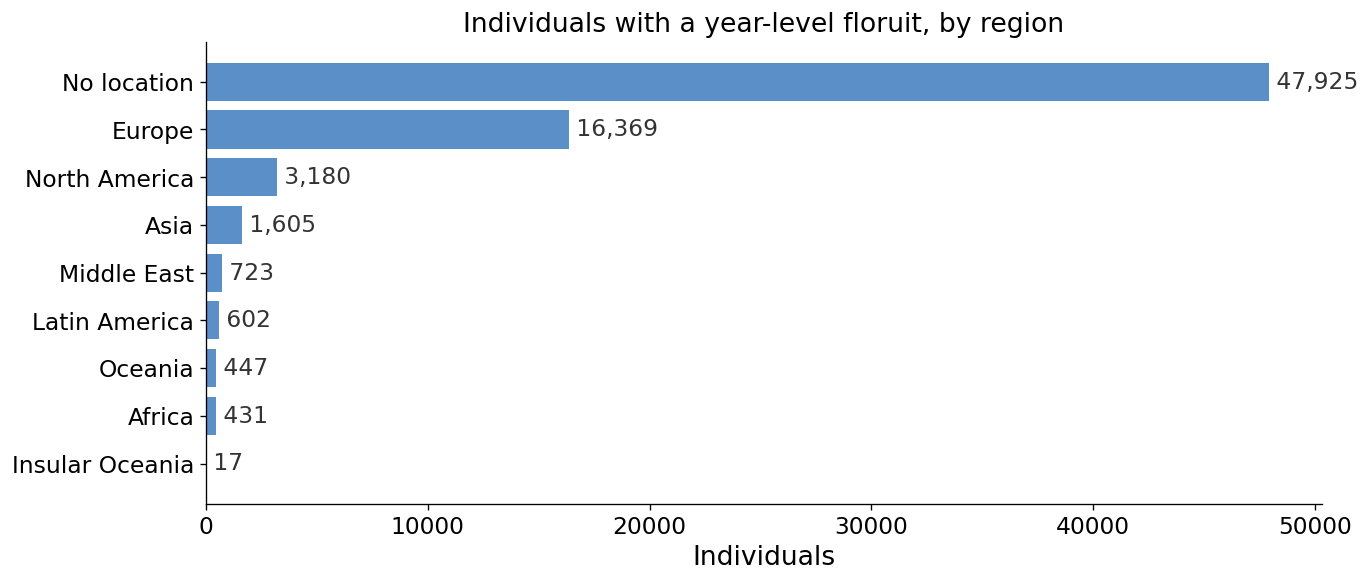

In [11]:
by_region = floruit.group_by('region').len().sort('len')

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.barh(by_region['region'], by_region['len'], color=MAIN_COLOR)
for y, value in enumerate(by_region['len']):
    ax.text(value, y, f' {value:,}', va='center', color=TEXT)
ax.set_xlabel('Individuals')
ax.set_title('Individuals with a year-level floruit, by region')
plt.show()